### Train/Test EDA

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import seaborn as sns

In [3]:
# SibSp - число братьев сестер и супргугов на борту
# Parch - число родителей и детей на борту
# Ticket - номер билета
# Fare - стоимость билета
# Cabin - номер каюты
# Embarked - порт посадки на корабль
# Pclass - класс билета пассажира
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
raw_train = train.copy()
raw_test = test.copy()

cols = [col for col in train.columns if col != 'Survived'] + ['Survived']
train = train[cols]

In [4]:
print(f'Training samples: {train.shape[0]}')
print(f'Test samples: {test.shape[0]}')
print(f'Train features: {train.shape[1]}')
print(f'Test features: {test.shape[1]}')

Training samples: 891
Test samples: 418
Train features: 12
Test features: 11


In [5]:
train.dtypes

PassengerId      int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
Survived         int64
dtype: object

In [6]:
display(train.head(5))
train.info()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    str    
 3   Sex          891 non-null    str    
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    str    
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    str    
 10  Embarked     889 non-null    str    
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
display(test.head(5))
test.info()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [8]:
pd.DataFrame({
    'train' : train.isna().sum(),
    'test' : test.isna().sum()
})

,train,test
Age,177,86.0
Cabin,687,327.0
Embarked,2,0.0
Fare,0,1.0
Name,0,0.0
Parch,0,0.0
PassengerId,0,0.0
Pclass,0,0.0
Sex,0,0.0
SibSp,0,0.0


### В Age, Cabin, Embarked, Fate(test) есть пропущенные значения - нужно будет их обработать

In [9]:
unique_count = pd.DataFrame({
    'train' : train.nunique(dropna=True),
    'test' : test.nunique(dropna=True)
})
unique_count

,train,test
Age,88,79.0
Cabin,147,76.0
Embarked,3,3.0
Fare,248,169.0
Name,891,418.0
Parch,7,8.0
PassengerId,891,418.0
Pclass,3,3.0
Sex,2,2.0
SibSp,7,7.0


### Константные признаки отсутствуют. Признак Sex принимает всего два значения - male / female. Можно закодировать 0 / 1

In [10]:
train['Sex'] = train['Sex'].map({'male': 1, 'female': 0})
test['Sex'] = test['Sex'].map({'male': 1, 'female': 0})

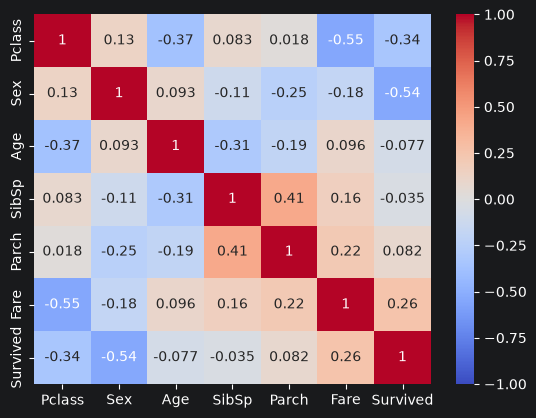

In [11]:
numerical = train.select_dtypes(include='number').drop(columns='PassengerId')
sns.heatmap(numerical.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, center = 0)
plt.show()

### Больше всего Survived коррелирует с
Fare: 0.26 - пассажиры с более дорогими билетами выживали чаще <br>
Pclass: -0.34- пассажиры с более престижным номером класса выживали чаще (1 class > 2 class > 3 class) <br>
Sex: -0.54 - пассажиры женского пола выживали чаще

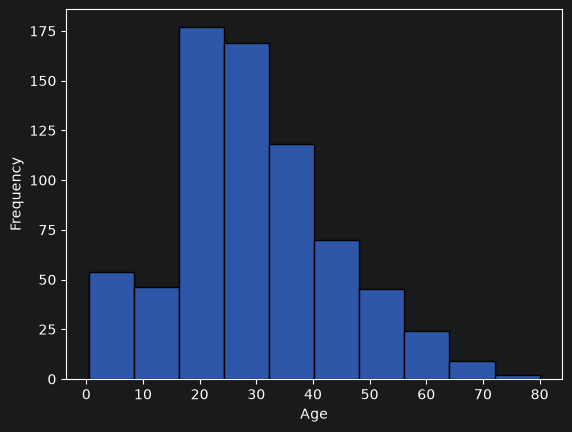

In [93]:
sns.histplot(train['Age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Большее число пассажиров находятся в возрасте от 20 до 40 лет, пожилых заметно меньше

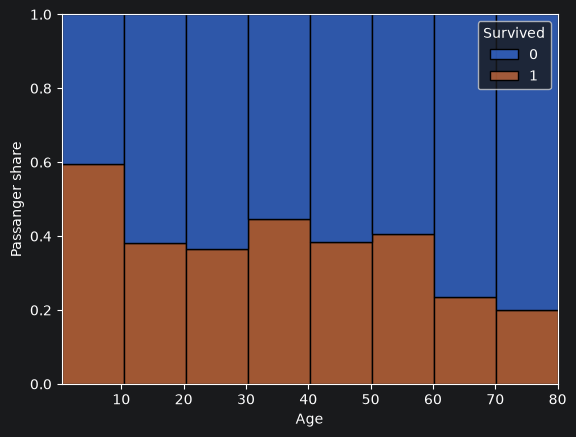

In [79]:
sns.histplot(data=train,  x="Age", hue="Survived", binwidth=10, multiple="fill")
plt.ylabel('Passanger share')
plt.show()


plt.show()

### Доля выживших различается между возрастными группами.
до 10 лет - ~60% выжило <br>
10-60 лет - ~40% выжило <br>
60+ лет - ~20% выжило

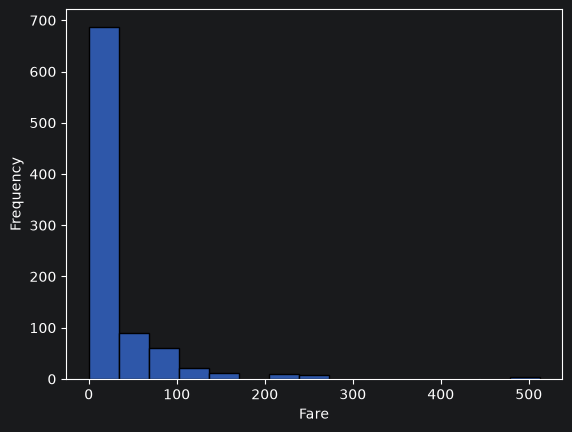

In [61]:
sns.histplot(train['Fare'], bins=15)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

### Распределение неравномерное с длинным хвостом справа. Пассажиров с дорогостоящими билетами значительно меньше


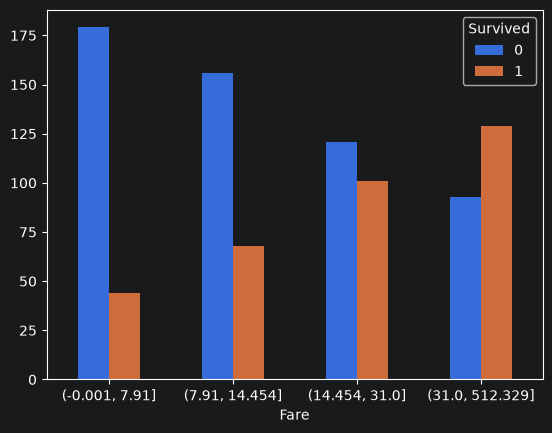

In [86]:
fare_groups = pd.qcut(train['Fare'],4)
counts = pd.crosstab(fare_groups, train['Survived'])
counts.sort_index().plot.bar()
plt.xticks(rotation=0)
plt.show()

### Проведено разбиение по квантилям. Заметно, что пассажиры с более дорогими билетами выживали чаще

<Axes: xlabel='Sex'>

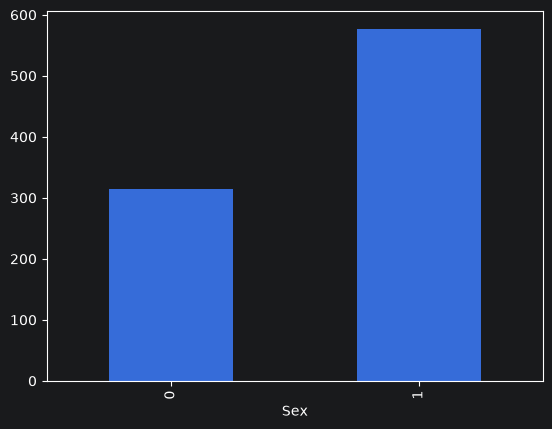

In [92]:
train["Sex"].value_counts().sort_index().plot.bar()


<Axes: xlabel='Pclass'>

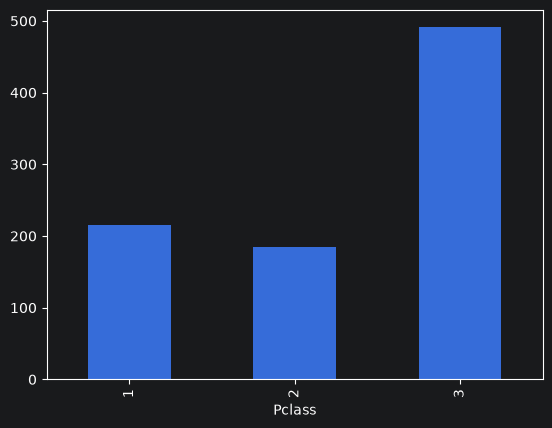

In [38]:
train["Pclass"].value_counts().sort_index().plot.bar()

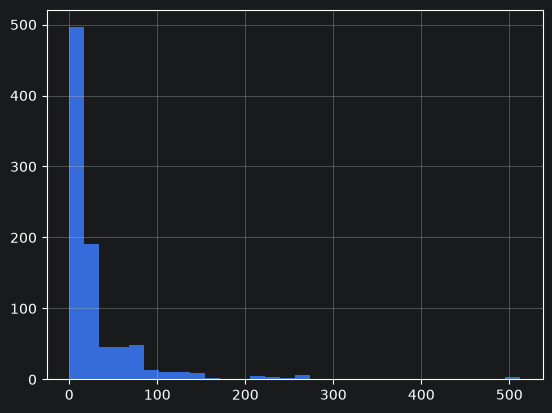

In [27]:
train['Fare'].hist(bins=30)
plt.show()